# Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv(r"C:\Users\moham\OneDrive\Desktop\DEPI project\calorix_raw_dataset.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\moham\\OneDrive\\Desktop\\DEPI project\\calorix_raw_dataset.csv'

In [ ]:
data.head()

,recipe_id,name,name_ar,category,cuisine,difficulty,dietary_goal,meal_occasion,prep_time_min,cook_time_min,...,allergens,health_score,protein_density,glycemic_index_level,calorie_category,macro_balance_label,bmi_suitability,budget_level,avg_rating,review_count
0,100000,Grilled Chicken Breast,صدر دجاج مشوي,Main Course,Mediterranean,Easy,High Protein / Weight Loss,Dinner,8.0,19.0,...,NaN,46.8,10.65,Low,Low,High Protein,Overweight,Low,5.00,NaN
1,100001,Egg White Omelette,عجة بياض البيض,Breakfast,International,Very Easy,High Protein / Low Cal,Breakfast,6.0,6.0,...,Eggs,53.1,12.65,Low,Very Low,High Protein,Normal,Low,4.33,3.0
2,100002,Tuna Salad Bowl,بول سلطة التونة,Salad,Mediterranean,Very Easy,Weight Loss,Lunch,11.0,0.0,...,Seafood,57.0,16.14,Low,Very Low,High Protein,Overweight,Low,3.00,2.0
3,100003,Protein Pancakes,بانكيك البروتين,Breakfast,American,Very Easy,Muscle Gain,Breakfast,5.0,11.0,...,Dairy|Eggs|Gluten,51.2,8.48,Medium,Low,High Protein,Underweight,Low,5.00,2.0
4,100004,Greek Yogurt Parfait,بارفيه الزبادي اليوناني,Snack,International,Very Easy,Healthy Snack,Snack,4.0,0.0,...,Dairy,50.3,6.64,High,Low,Mixed,Normal,Low,3.43,7.0


# Data Preprocessing

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2062 entries, 0 to 2061
Data columns (total 38 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   recipe_id             2062 non-null   int64  
 1   name                  2062 non-null   object 
 2   name_ar               2062 non-null   object 
 3   category              2062 non-null   object 
 4   cuisine               2062 non-null   object 
 5   difficulty            2062 non-null   object 
 6   dietary_goal          2062 non-null   object 
 7   meal_occasion         2062 non-null   object 
 8   prep_time_min         1990 non-null   float64
 9   cook_time_min         1975 non-null   float64
 10  minutes               2062 non-null   int64  
 11  n_steps               2062 non-null   int64  
 12  n_ingredients         2062 non-null   int64  
 13  servings              2062 non-null   int64  
 14  calories              2062 non-null   int64  
 15  protein_g            

In [ ]:
data.shape

(2062, 38)

In [ ]:
data.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2057    False
2058    False
2059    False
2060    False
2061    False
Length: 2062, dtype: bool

In [ ]:
data = data.drop_duplicates()

In [ ]:
data.describe()

,recipe_id,prep_time_min,cook_time_min,minutes,n_steps,n_ingredients,servings,calories,protein_g,carbohydrates_g,...,cholesterol_mg,vitamin_c_mg,calcium_mg,iron_mg,is_vegan,is_vegetarian,health_score,protein_density,avg_rating,review_count
count,2062.000000,1990.000000,1975.000000,2062.000000,2062.000000,2062.000000,2062.000000,2062.000000,2062.000000,2062.000000,...,1881.000000,1798.000000,1841.000000,1860.000000,2062.000000,2062.000000,2062.000000,1943.000000,1801.000000,1846.000000
mean,101040.054316,9.804020,12.345316,33.314743,6.351600,8.571775,2.764791,323.890883,20.744617,32.029195,...,60.671451,22.923359,95.552960,2.583871,0.228904,0.674103,52.299661,6.232476,4.067729,5.017335
std,597.116435,5.508874,13.261085,111.377243,3.105308,6.646070,1.641132,215.885263,18.713561,17.355642,...,93.533715,23.372858,71.383521,1.440014,0.420229,0.468823,5.983566,3.294059,0.778290,5.396448
min,100000.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000,-5.000000,2.000000,...,0.000000,0.500000,5.000000,0.300000,0.000000,0.000000,34.500000,0.440000,-1.000000,1.000000
25%,100524.250000,5.000000,0.000000,9.000000,4.000000,7.000000,2.000000,222.000000,9.700000,17.600000,...,0.000000,8.800000,50.000000,1.700000,0.000000,0.000000,48.300000,3.560000,3.800000,3.000000
50%,101041.500000,10.000000,10.000000,19.000000,6.000000,8.000000,2.000000,306.000000,17.100000,29.750000,...,13.000000,15.800000,70.000000,2.400000,0.000000,1.000000,52.300000,5.440000,4.200000,4.000000
75%,101558.750000,13.000000,21.000000,34.000000,9.000000,9.000000,4.000000,393.750000,30.200000,44.900000,...,85.000000,28.000000,120.000000,3.300000,0.000000,1.000000,56.700000,8.715000,4.500000,6.000000
max,102062.000000,30.000000,240.000000,1440.000000,14.000000,100.000000,12.000000,2500.000000,220.000000,78.000000,...,426.000000,142.000000,380.000000,8.000000,1.000000,1.000000,67.700000,18.350000,7.000000,59.000000


In [ ]:
data.describe(include='object')

,name,name_ar,category,cuisine,difficulty,dietary_goal,meal_occasion,allergens,glycemic_index_level,calorie_category,macro_balance_label,bmi_suitability,budget_level
count,2062,2062,2062,2062,2062,2062,2062,1592,2062,2062,2062,2062,2062
unique,98,107,9,11,8,37,6,18,3,4,5,3,2
top,Stuffed Bell Peppers,دجاج مقلي بالخضار,Main Course,International,Easy,Balanced,Dinner,Dairy,Medium,Low,High Carb,Normal,Low
freq,42,42,802,905,963,293,744,255,867,1214,828,1686,1055


# Clean using fillna

encode using  LabelEncode

scale using standardScaler

for all_columns and please write notes why use each technique and explain results

In [ ]:
data.isnull().sum()

In [ ]:
(data.isnull().sum() / len(data)) * 100

In [ ]:
# data['review_count']=data['review_count'].fillna(data['review_count'].mode()[0])
# data['allergens']=data['allergens'].fillna(data['allergens'].mode()[0])
# data['prep_time_min']=data['prep_time_min'].fillna(data['prep_time_min'].mode()[0])
# data['cook_time_min']=data['cook_time_min'].fillna(data['cook_time_min'].mode()[0])
# data['saturated_fat_g']=data['saturated_fat_g'].fillna(data['saturated_fat_g'].mode()[0])
# data['fiber_g']=data['fiber_g'].fillna(data['fiber_g'].mode()[0])
# data['sodium_mg']=data['sodium_mg'].fillna(data['sodium_mg'].mode()[0])
# data['cholesterol_mg']=data['cholesterol_mg'].fillna(data['cholesterol_mg'].mode()[0])
# data['vitamin_c_mg']=data['vitamin_c_mg'].fillna(data['vitamin_c_mg'].mode()[0])
# data['calcium_mg']=data['calcium_mg'].fillna(data['calcium_mg'].mode()[0])
# data['avg_rating']=data['avg_rating'].fillna(data['avg_rating'].mode()[0])

In [ ]:
data.isnull().sum()

# EDA

Visualize patterns using seaborn, matplotlib and please explain each graph

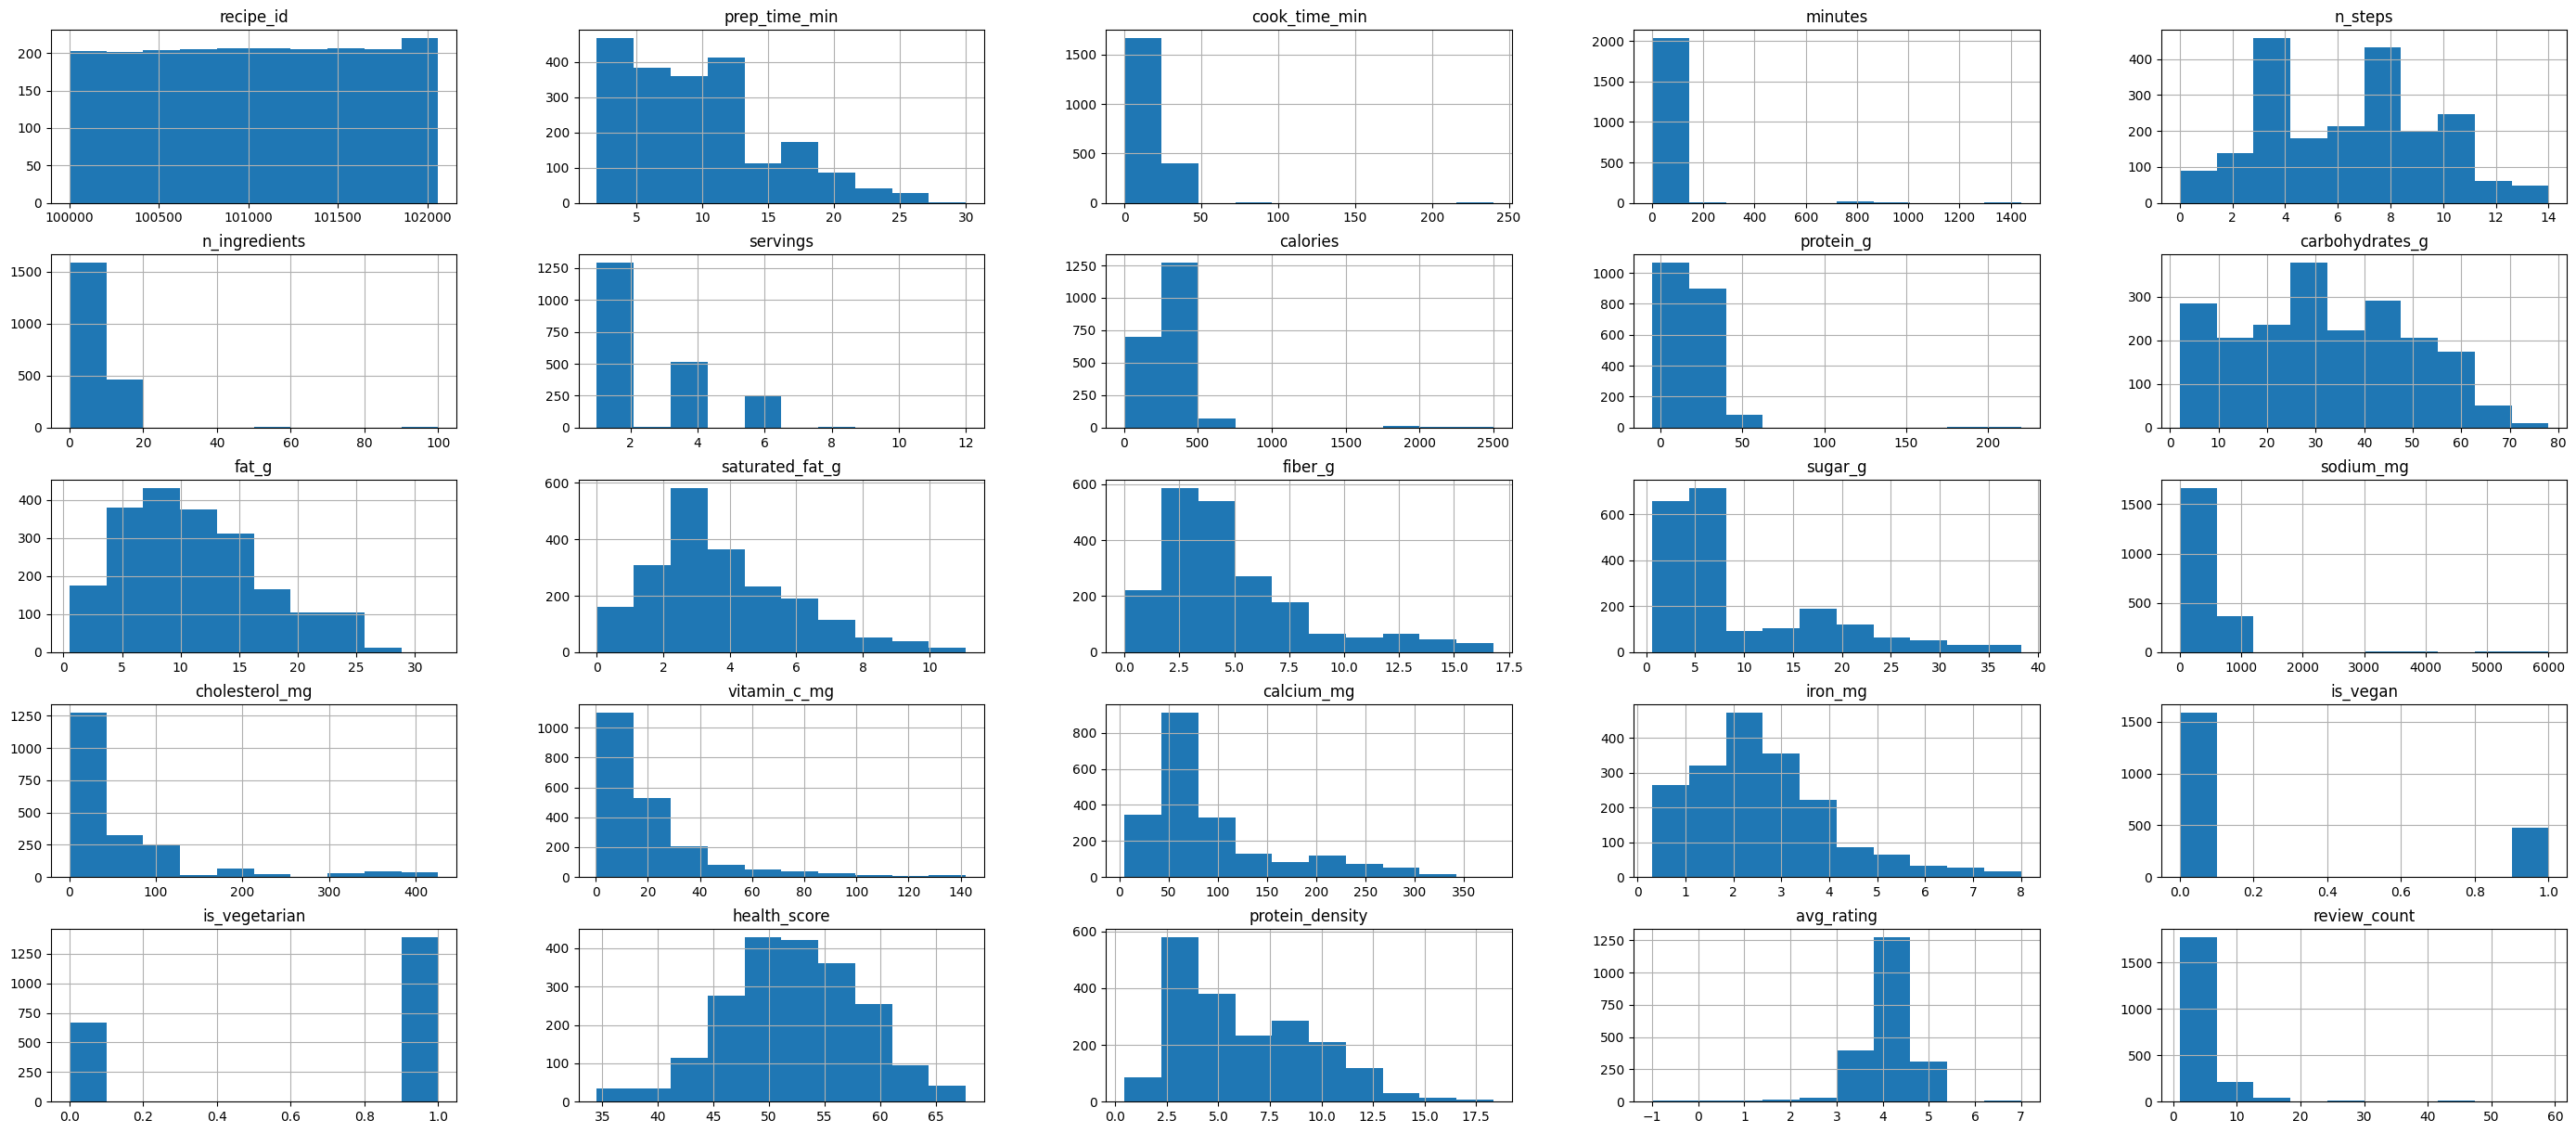

In [ ]:
data.hist(figsize=(35,15))
plt.show()

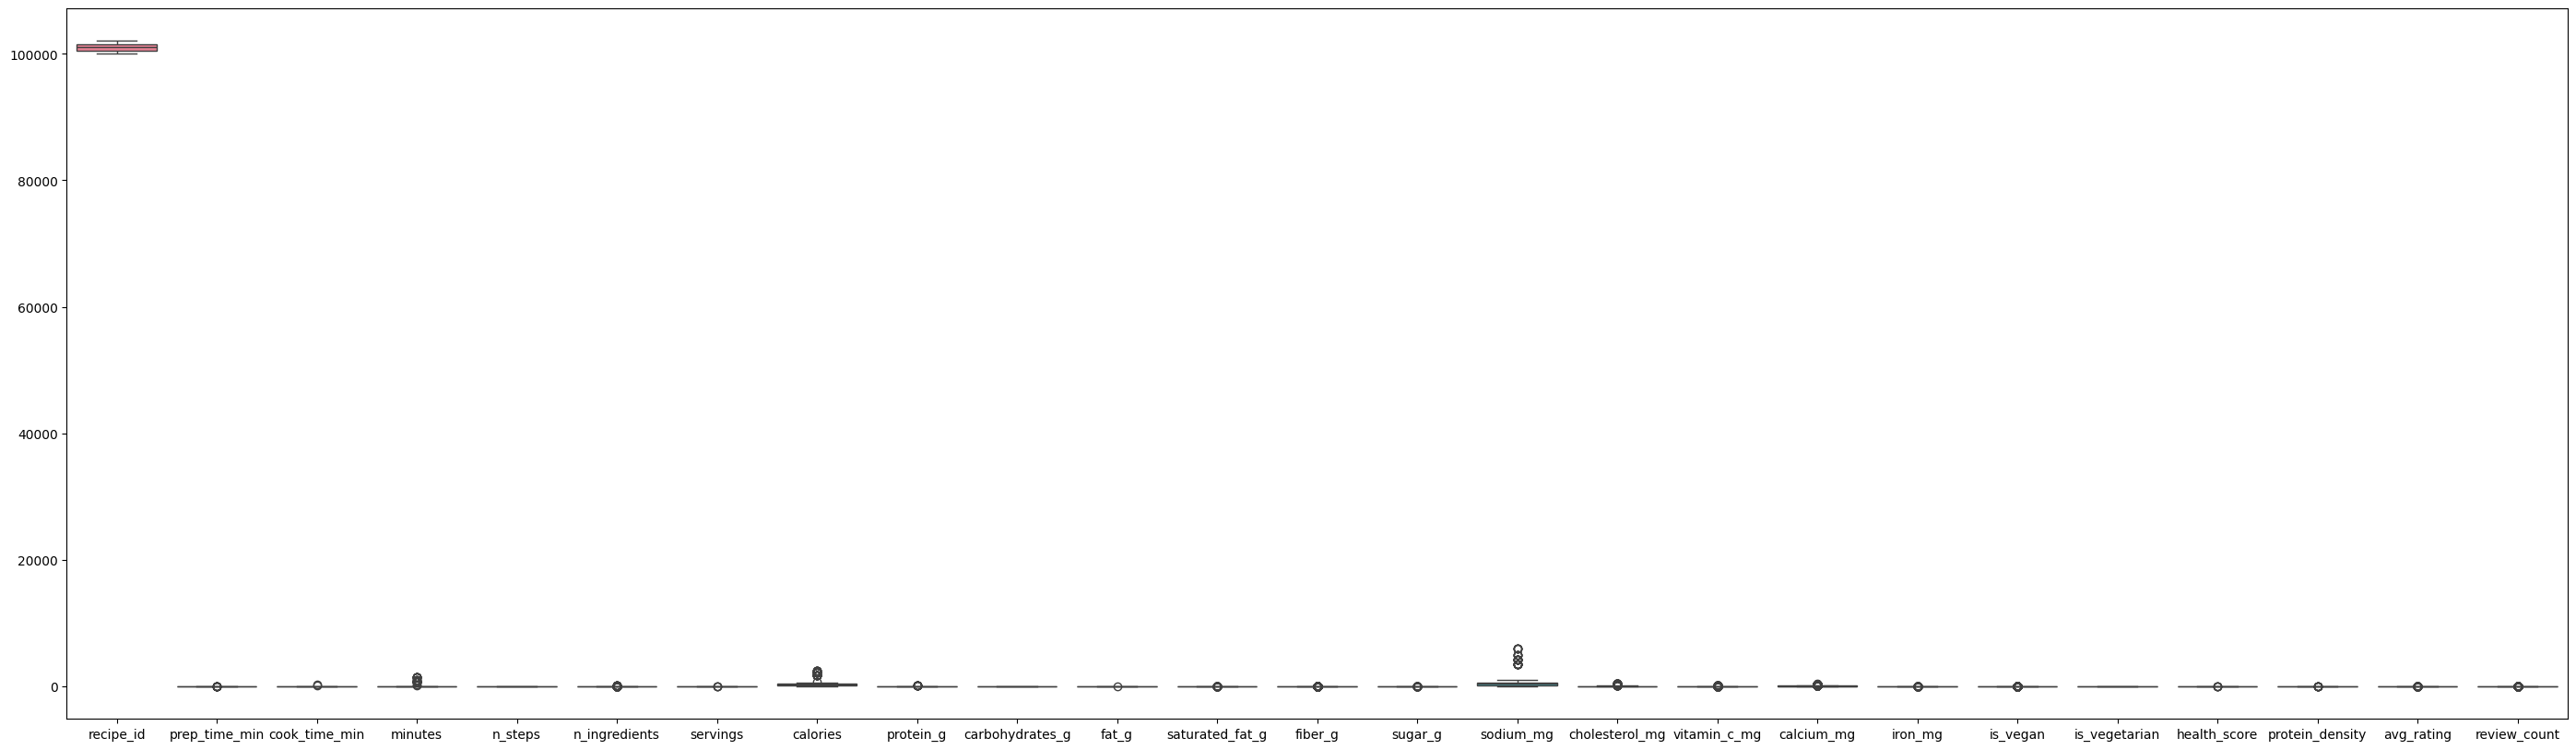

In [ ]:
plt.figure(figsize=(35,10))
sns.boxplot(data=data)
plt.show()

In [ ]:
for col in data.select_dtypes(include='object').columns:
    print(data[col].value_counts())
    print("-"*30)

name
Stuffed Bell Peppers      42
Minestrone Soup           42
Greek Yogurt Parfait      42
Chicken Shawarma Bowl     42
Chicken Vegetable Soup    42
                          ..
Spinach Smoothie           1
Chicken Tacos              1
Guacamole                  1
Burrito Bowl               1
Baked Sea Bass             1
Name: count, Length: 98, dtype: int64
------------------------------
name_ar
دجاج مقلي بالخضار     42
دجاج تيكا ماسالا      42
صدر دجاج مشوي         41
كرات الطاقة           41
بول أرز باللحمة       41
                      ..
طبقات زبادي يوناني     1
أرز قرنبيط مقلي        1
سموذي السبانخ          1
تاكو دجاج              1
باس البحر المشوي       1
Name: count, Length: 107, dtype: int64
------------------------------
category
Main Course      802
Breakfast        332
Snack            254
Beverage         209
Soup             170
Salad            130
Dessert           83
Light Meal        42
Dessert/Snack     40
Name: count, dtype: int64
------------------------------

# ML_Model_1

In [3]:
import pandas as pd
df=pd.read_csv('clean_nutrition_dataset.csv')
df.head(100)

,fdc_id,food_name,carbs,calories,fiber,iron,magnesium,protein,sodium,fat,category
0,1105904,WESSON Vegetable Oil 1 GAL,0.00,867.0,0.0,0.00,0.0,0.00,0.0,93.33,Others
1,1105905,SWANSON BROTH BEEF,0.42,4.0,0.0,0.00,0.0,0.83,346.0,0.00,Others
2,1105906,CAMPBELL'S SLOW KETTLE SOUP CLAM CHOWDER,6.12,82.0,0.4,0.24,0.0,2.45,363.0,5.31,Others
3,1105907,CAMPBELL'S SLOW KETTLE SOUP CHEESE BROCCOLI,5.31,82.0,0.4,0.16,0.0,1.22,322.0,6.12,Others
4,1105908,SWANSON BROTH CHICKEN,0.42,4.0,0.0,0.00,0.0,0.83,15.0,0.00,Others
...,...,...,...,...,...,...,...,...,...,...,...
95,1105999,Pork Loin Chop Porterhouse,0.00,80.0,0.0,0.00,0.0,17.86,304.0,8.93,Others
96,1106000,"Pork Loin Bone In Center Cut All Natural 1/8""""...",0.00,71.0,0.0,0.64,0.0,18.75,286.0,8.04,Others
97,1106001,Pork Loin Bone In Center Cut False Lean Remove...,0.00,71.0,0.0,0.32,0.0,19.64,45.0,8.04,Others
98,1106002,Pork Loin Bone In Chine Removed Chop with Jala...,1.79,71.0,0.0,0.64,0.0,16.96,812.0,8.04,Others


Text(0.5, 1.0, 'Correlation Heatmap')

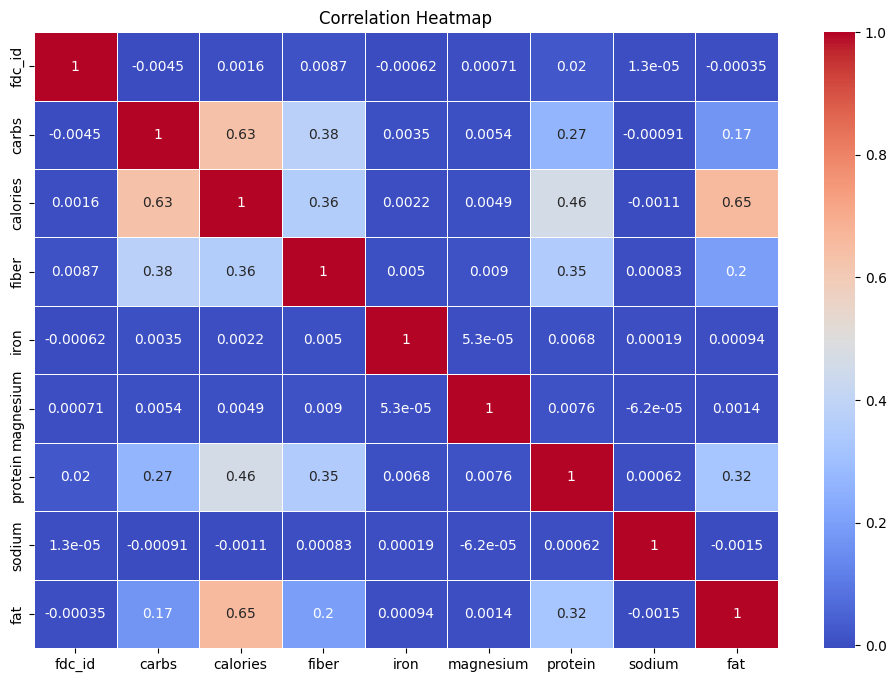

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
heatmap_data = df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', linewidths=0.5,)
plt.title('Correlation Heatmap')

<Figure size 2000x1000 with 0 Axes>

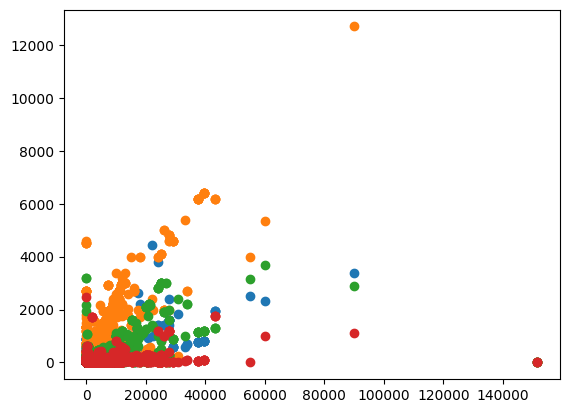

<Figure size 2000x1000 with 0 Axes>

In [5]:
figure1=plt.scatter(x='calories',y='protein',data=df)
figure2=plt.scatter(x='calories',y='carbs',data=df)
figure3=plt.scatter(x='calories',y='fat',data=df)
figure4=plt.scatter(x='calories',y='fiber',data=df)
plt.figure(figsize=(20,10))


## Handling outlayers

In [6]:


def remove_outliers_iqr(df, columns):
    cleaned_df = df.copy()
    
    for col in columns:
        Q1 = cleaned_df[col].quantile(0.25)
        Q3 = cleaned_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        cleaned_df = cleaned_df[(cleaned_df[col] >= lower) & (cleaned_df[col] <= upper)]
        
    return cleaned_df

num_cols = ['carbs', 'calories', 'fiber', 'iron', 'magnesium', 'protein', 'sodium', 'fat']

df_clean = remove_outliers_iqr(df, num_cols)
print("Before:", df.shape)
print("After :", df_clean.shape)

Before: (1913614, 11)
After : (1416969, 11)


In [7]:
df_clean.head()

,fdc_id,food_name,carbs,calories,fiber,iron,magnesium,protein,sodium,fat,category
1,1105905,SWANSON BROTH BEEF,0.42,4.0,0.0,0.00,0.0,0.83,346.0,0.00,Others
2,1105906,CAMPBELL'S SLOW KETTLE SOUP CLAM CHOWDER,6.12,82.0,0.4,0.24,0.0,2.45,363.0,5.31,Others
3,1105907,CAMPBELL'S SLOW KETTLE SOUP CHEESE BROCCOLI,5.31,82.0,0.4,0.16,0.0,1.22,322.0,6.12,Others
4,1105908,SWANSON BROTH CHICKEN,0.42,4.0,0.0,0.00,0.0,0.83,15.0,0.00,Others
5,1105909,CAMPBELL'S SOUP BEAN AND HAM,10.61,61.0,2.4,0.82,0.0,3.67,306.0,0.61,Others


<Figure size 2000x1000 with 0 Axes>

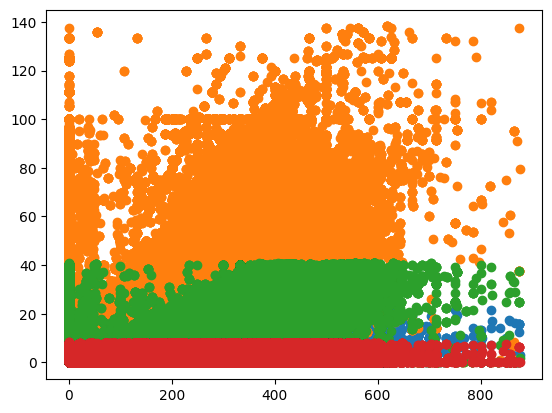

<Figure size 2000x1000 with 0 Axes>

In [ ]:
figure1=plt.scatter(x='calories',y='protein',data=df_clean)
figure2=plt.scatter(x='calories',y='carbs',data=df_clean)
figure3=plt.scatter(x='calories',y='fat',data=df_clean)
figure4=plt.scatter(x='calories',y='fiber',data=df_clean)
plt.figure(figsize=(20,10))


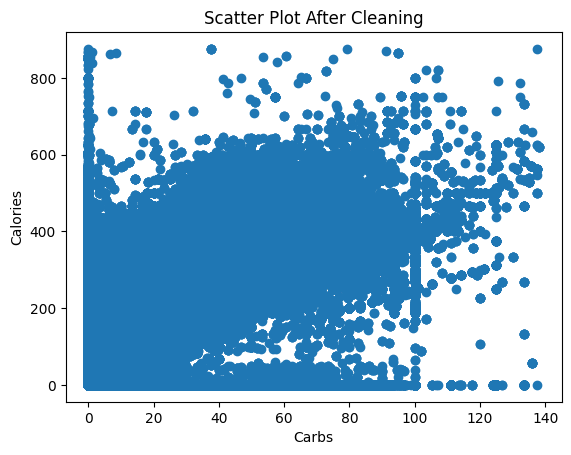

In [8]:
import matplotlib.pyplot as plt

plt.scatter(df_clean['carbs'], df_clean['calories'])
plt.xlabel("Carbs")
plt.ylabel("Calories")
plt.title("Scatter Plot After Cleaning")
plt.show()


## scaling

In [9]:
from sklearn.preprocessing import StandardScaler

features = ['carbs', 'fat', 'protein', 'fiber', 'iron', 'magnesium', 'sodium']
target = ['calories']

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X = scaler_X.fit_transform(df_clean[features])
y = scaler_y.fit_transform(df_clean[target])

## Feature ENG

In [18]:
import numpy as np

# Guard against zeros before ratios
df_clean['macro_sum'] = (df_clean['carbs'] + df_clean['protein'] + df_clean['fat']).replace(0, np.nan)
df_clean['calories'] = df_clean['calories'].replace(0, np.nan)

# Engineered features
df_clean['calorie_density'] = df_clean['calories'] / 100
df_clean['carb_ratio'] = df_clean['carbs'] / df_clean['macro_sum']
df_clean['protein_ratio'] = df_clean['protein'] / df_clean['macro_sum']
df_clean['fat_ratio'] = df_clean['fat'] / df_clean['macro_sum']
df_clean['nutrient_density'] = df_clean['macro_sum'] / df_clean['calories']

# Final feature list used downstream
final_features = [
    'carbs', 'fat', 'protein', 'fiber', 'iron', 'magnesium', 'sodium',
    'calorie_density',
    'carb_ratio', 'protein_ratio', 'fat_ratio',
    'nutrient_density'
 ]

# Clean up infinities and drop rows missing engineered features
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)
df_clean = df_clean.dropna(subset=final_features + ['calories'])

In [11]:
final_features = [
    'carbs', 'fat', 'protein', 'fiber', 'iron', 'magnesium', 'sodium',
    'calorie_density',
    'carb_ratio', 'protein_ratio', 'fat_ratio',
    'nutrient_density'
]

In [19]:
X = scaler_X.fit_transform(df_clean[final_features])
y = scaler_y.fit_transform(df_clean[['calories']])

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[final_features])

## Modeling

In [ ]:
from sklearn.cluster import KMeans

k = 6
kmeans = KMeans(n_clusters=k, random_state=42)
df_clean['cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
import numpy as np

embeddings = X_scaled  # already scaled
df_clean['embedding'] = list(embeddings)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from rapidfuzz import process, fuzz
import numpy as np

def find_closest_food(query):
    choices = df_clean['food_name'].values
    match, score, idx = process.extractOne(query, choices, scorer=fuzz.WRatio)
    return match

def recommend(query, top_n=5):

    # 1. Find closest matching food name
    food_name = find_closest_food(query)

    # 2. Get index
    idx = df_clean.index[df_clean['food_name'] == food_name][0]

    # 3. Vector
    food_vec = df_clean.loc[idx, 'embedding'].reshape(1, -1)

    # 4. Similarity
    sims = cosine_similarity(food_vec, np.vstack(df_clean['embedding'])).flatten()

    # 5. Sort
    df_clean['similarity'] = sims
    results = (
        df_clean.sort_values(by='similarity', ascending=False)
        [['food_name', 'category', 'similarity', 'cluster']]
        .head(top_n+1)[1:]
    )

    print(f"Input: {query}\nMatched: {food_name}")
    return results

In [ ]:
recommend("oats")

Input: oats
Matched: OEP Mini Flour Tort Boats 12Ct


,food_name,category,similarity,cluster
378495,Old El Paso Mini Flour Tortilla Taco Boats 12 ...,Others,1.0,1
553487,OEP Flr Trtilla Taco Boat 8Ct,Others,1.0,1
553597,OEP Mini Flour Tort Boats 12Ct,Others,1.0,1
788116,OEP Flr Trtilla Taco Boat 8Ct,Others,1.0,1
788352,OEP Sft Mini Flr TrtllBwl 20Ct,Others,1.0,1


## 2nd Model (prediction for callories)

the same featured features

In [21]:
final_features = [
    'carbs', 'fat', 'protein', 'fiber', 'iron', 'magnesium', 'sodium',
    'calorie_density',
    'carb_ratio', 'protein_ratio', 'fat_ratio',
    'nutrient_density'
]

X = df_clean[final_features]
y = df_clean['calories']

normalized


In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1))

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

XGBoost Model

In [24]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror'
)

xgb.fit(X_train, y_train.ravel())

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


Evaluate XGBoost

In [26]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
pred_scaled = xgb.predict(X_test).reshape(-1,1)
pred = scaler_y.inverse_transform(pred_scaled)
y_real = scaler_y.inverse_transform(y_test)

rmse = np.sqrt(mean_squared_error(y_real, pred))
mae = mean_absolute_error(y_real, pred)

print("XGBoost RMSE:", rmse)
print("XGBoost MAE :", mae)

XGBoost RMSE: 1.5654183997718825
XGBoost MAE : 0.9677981962088257


predction

In [27]:
def predict_calories_xgb(sample_dict):

    # Convert dictionary → DataFrame
    df_inp = pd.DataFrame([sample_dict])[final_features]

    # Scale input
    scaled = scaler_X.transform(df_inp)

    # Predict (scaled calories)
    pred_scaled = xgb.predict(scaled).reshape(-1,1)

    # Convert back to real calories
    predicted = scaler_y.inverse_transform(pred_scaled)

    return predicted[0][0]  # return number only


# Example sample input
sample = {
    'carbs': 30,
    'fat': 5,
    'protein': 12,
    'fiber': 4,
    'iron': 2,
    'magnesium': 20,
    'sodium': 180,
    'calorie_density': 1.3,
    'carb_ratio': 0.55,
    'protein_ratio': 0.25,
    'fat_ratio': 0.20,
    'nutrient_density': 0.03
}

cal = predict_calories_xgb(sample)
print("Predicted Calories:", cal)

Predicted Calories: 148.16763
